# Polynomial Regression

## Objective

* Understand the concept of Polynomial Regression.
* Learn how Polynomial Regression extends Linear Regression.
* Implement Polynomial Regression from scratch and using Scikit-learn.
* Evaluate model performance using appropriate metrics.

## Prerequisites

* Basic understanding of Linear Regression
* Knowledge of Python programming
* Familiarity with NumPy and Pandas

## Dataset

The implementation uses a real-world dataset obtained from Kaggle.

## Credits

This notebook was created as part of the Gradientts Machine Learning Internship program.


# Dataset Information

**Dataset Name:** Salary Dataset

**Kaggle Link:**
https://www.kaggle.com/datasets/abhishek14398/salary-dataset-simple-linear-regression

**Reason for Selection:**
This dataset helps demonstrate how Polynomial Regression captures non-linear relationships between years of experience and salary.

**Credits:** Kaggle

In [1]:
# Numerical computations
import numpy as np

# Data manipulation and analysis
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## Theory Recap

Polynomial Regression is an extension of Linear Regression that models non-linear relationships between the independent and dependent variables by introducing polynomial terms of the input features.

### Polynomial Regression Equation

ŷ = β₀ + β₁x + β₂x² + ... + βₙxⁿ

Where:

* **ŷ** = Predicted value
* **β₀** = Intercept term
* **β₁, β₂, ..., βₙ** = Coefficients of polynomial terms
* **x** = Input feature
* **n** = Degree of the polynomial

### Key Idea

Although the relationship between the input feature and the output is non-linear, Polynomial Regression is still considered a **linear model** because it remains linear with respect to its parameters (coefficients).


In [2]:
import pandas as pd

df = pd.read_csv("data/Salary_Data.csv")

df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [3]:
X = df.iloc[:, :-1]   # Features
y = df.iloc[:, -1]    # Target

print(X.head())
print(y.head())

   YearsExperience
0              1.1
1              1.3
2              1.5
3              2.0
4              2.2
0    39343
1    46205
2    37731
3    43525
4    39891
Name: Salary, dtype: int64


## Dataset Exploration

Before building the model, it is important to understand the structure of the dataset. We will examine the data types, summary statistics, and check for missing values.


In [4]:
# Display dataset information
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nSummary Statistics:")
display(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (30, 2)

Column Names:
Index(['YearsExperience', 'Salary'], dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes

Summary Statistics:


,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000



Missing Values:
YearsExperience    0
Salary             0
dtype: int64


## Data Preprocessing

In this step, we separate the independent variable and dependent variable. Then, we split the dataset into training and testing sets. This helps us evaluate how well the model generalizes to unseen data.


In [5]:
# Independent variable (feature)
X = df[['YearsExperience']]

# Dependent variable (target)
y = df['Salary']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display the shapes
print("Training Feature Shape:", X_train.shape)
print("Testing Feature Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Feature Shape: (24, 1)
Testing Feature Shape: (6, 1)
Training Target Shape: (24,)
Testing Target Shape: (6,)


# Polynomial Regression From Scratch (NumPy)

In this section, Polynomial Regression is implemented using NumPy without relying on scikit-learn.

In [6]:
import numpy as np

X_np = X.values.flatten()

X_poly = np.column_stack((
    np.ones(len(X_np)),
    X_np,
    X_np**2
))

y_np = y.values

In [7]:
theta = np.linalg.inv(X_poly.T @ X_poly) @ X_poly.T @ y_np

print("Coefficients:")
print(theta)

Coefficients:
[2.62149327e+04 9.25928389e+03 1.63925663e+01]


In [8]:
y_pred_scratch = X_poly @ theta

## Polynomial Regression using Scikit-learn

In this section, we transform the original feature into polynomial features and train a Polynomial Regression model using Scikit-learn. By increasing the polynomial degree, the model can capture non-linear relationships in the data.


In [9]:
# Create polynomial features of degree 2
poly = PolynomialFeatures(degree=2)

# Transform the training and testing data
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Create and train the model
model = LinearRegression()
model.fit(X_train_poly, y_train)

print("Polynomial Regression model trained successfully!")

Polynomial Regression model trained successfully!


## Model Evaluation

After training the Polynomial Regression model, we evaluate its performance using evaluation metrics such as Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score. These metrics help us understand how accurately the model predicts salary values.


In [10]:
# Make predictions
y_pred = model.predict(X_test_poly)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display results
print("Mean Squared Error (MSE):", round(mse, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R² Score:", round(r2, 4))

Mean Squared Error (MSE): 52527916.37
Root Mean Squared Error (RMSE): 7247.61
R² Score: 0.8972


## Visualization: Actual vs Predicted Values

This plot compares the actual salary values with the predicted salary values obtained from the Polynomial Regression model. A closer alignment indicates better model performance.


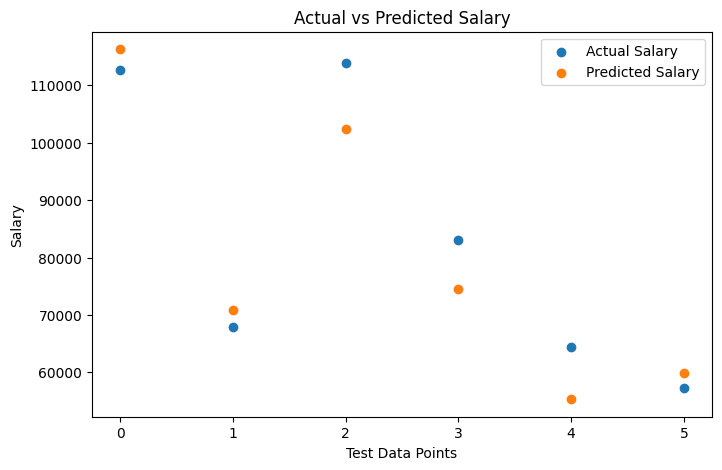

In [11]:
# Actual vs Predicted Values
plt.figure(figsize=(8, 5))

plt.scatter(
    range(len(y_test)),
    y_test,
    label='Actual Salary'
)

plt.scatter(
    range(len(y_pred)),
    y_pred,
    label='Predicted Salary'
)

plt.title('Actual vs Predicted Salary')
plt.xlabel('Test Data Points')
plt.ylabel('Salary')
plt.legend()

plt.show()

## Visualization: Polynomial Regression Curve

This graph shows how the Polynomial Regression model fits the relationship between Years of Experience and Salary.


c:\Users\harshitha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


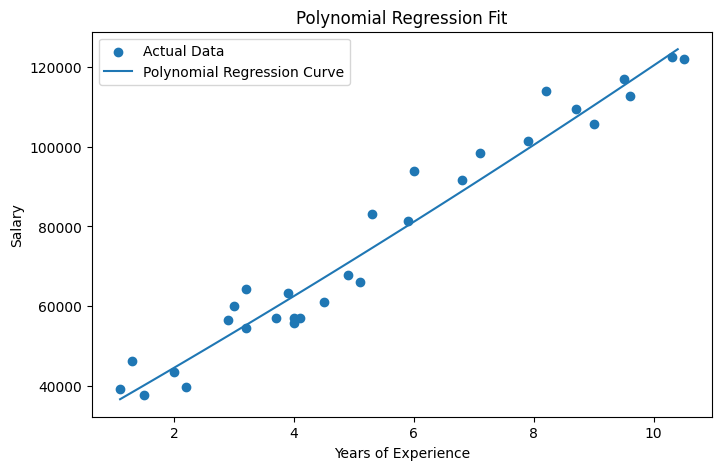

In [12]:
# Create smooth values for plotting
X_grid = np.arange(
    X.min().values[0],
    X.max().values[0],
    0.1
).reshape(-1, 1)

# Transform the grid values
X_grid_poly = poly.transform(X_grid)

# Predict salaries
y_grid_pred = model.predict(X_grid_poly)

# Plot
plt.figure(figsize=(8, 5))

plt.scatter(
    X,
    y,
    label='Actual Data'
)

plt.plot(
    X_grid,
    y_grid_pred,
    label='Polynomial Regression Curve'
)

plt.title('Polynomial Regression Fit')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()

plt.show()

## Hyperparameter Experiment

The degree of the polynomial determines the complexity of the model. In this experiment, we compare the performance of Polynomial Regression models with different polynomial degrees using the R² Score.


In [13]:
degrees = [1, 2, 3, 4]

for degree in degrees:
    
    # Generate polynomial features
    poly_exp = PolynomialFeatures(degree=degree)
    
    X_train_poly_exp = poly_exp.fit_transform(X_train)
    X_test_poly_exp = poly_exp.transform(X_test)
    
    # Train model
    model_exp = LinearRegression()
    model_exp.fit(X_train_poly_exp, y_train)
    
    # Predictions
    y_pred_exp = model_exp.predict(X_test_poly_exp)
    
    # Evaluate
    r2 = r2_score(y_test, y_pred_exp)
    
    print(f"Degree {degree}: R² Score = {r2:.4f}")

Degree 1: R² Score = 0.9024
Degree 2: R² Score = 0.8972
Degree 3: R² Score = 0.9048
Degree 4: R² Score = 0.9030


## Key Takeaways

1. Polynomial Regression extends Linear Regression to capture non-linear relationships.
2. The polynomial degree controls model complexity.
3. Higher-degree polynomials may lead to overfitting.
4. Evaluation metrics such as RMSE and R² help assess model performance.
5. Visualizations provide insights into how well the model fits the data.


## Interview Corner

### Question:

Why is Polynomial Regression considered a linear model?

### Answer:

Polynomial Regression is considered a linear model because it is linear with respect to its parameters (coefficients), even though it models non-linear relationships between the input features and the target variable.


## Final Equation

y = β₀ + β₁x + β₂x² + ... + βₙxⁿ

Where:
- y = predicted value
- β = coefficients
- x = input feature
- n = polynomial degree

### Significance
This equation helps model non-linear relationships.